> Projeto Desenvolve <br>
Programação Intermediária com Python <br>
Profa. Camila Laranjeira (mila@projetodesenvolve.com.br) <br>

# 4.2 - APIs


## Exercícios 🔭🌌🪐

Vamos acessar as APIs da NASA para ver algumas imagens interessantes capturadas universo afora!

#### Q1.
Crie uma chave no site oficial:
* https://api.nasa.gov

Vamos armazenar a chave de forma segura! <br>
Salve a sua chave em um arquivo `key.json` na forma:
`API_KEY=SUA_CHAVE`

Adicione o nome do arquivo `key.json` ao `.gitignore` do repositório que você fará upload da atividade.
Para isso basta abrir o arquivo `.gitignore` na pasta raíz do repositório (ou criar um caso ele não exista). Dentro do arquivo, apenas adiciona o nome do arquivo que deseja ignorar.

#### Q2. 🛰 Astronomy Picture of the Day (APOD) 🌌
> Antes de fazer os exercícios, devo te lembrar que existem limites de acesso às APIs, descritas na página principal, portanto pega leve na tentativa e erro na hora de testar seu código.

<img width=500 src=https://apod.nasa.gov/apod/image/2407/M24-HaLRGB-RC51_1024.jpg>

A primeira API que acessaremos é a mais popular de todas: astronomy picture of the day (foto astronômica do dia).

Faça uma requisição GET para a URL da API que retorna a imagem do dia! Essa é fácil já que são os valores padrão da rota principal:
* URL base: `'https://api.nasa.gov/planetary/apod'`
* Endpoint: não precisa preencher, acessaremos a raíz da API.
* Query params: preencha `api_key` com a sua chave de autenticação. Se animar mexer em outros parâmetros veja [a documentação](https://api.nasa.gov).

Ao receber a resposta (um json), você deve:
* Imprimir os campos `copyright` e `explanation`
* Com as biblioteca scikit-images e matplotlib, apresente a imagem a partir do campo `url` ou `hdurl`, e preencha o título do plot com o campo `title` do json. Uma dica de código a seguir.
```python
from skimage import io
img = io.imread(url)
## plot a matriz img com matplotlib (imshow)
```   

Copyright: Gianni Tumino

Text:
Keighley Rockcliffe  
(NASA
GSFC, 
UMBC CSST, 
CRESST II)

Explanation: No, Earth did not recently acquire six more moons!  Today’s APOD is a combination of images following the Moon, Venus, and the Pleiades across a southern Sicilian sky as twilight turned to evening on April 19. From 2023 to 2029, the Pleiades' and the Moon “visit" each other once per month due to the Pleiades' location in the ecliptic plane. April 2026 saw the celestial alignment of their visit with Venus.  About six stars in the Pleiades cluster (Messier 45) are typically visible with the unaided eye. Due to the cluster’s visibility across the world, there are many myths and legends across cultures associated with the Pleiades. The Haudenosaunee people of North America, for example, say that seven boys danced so enthusiastically that they lifted off into the sky. Astronomers recently found thousands more Pleiades members, showing that after thousands of years of gazing upon this clus

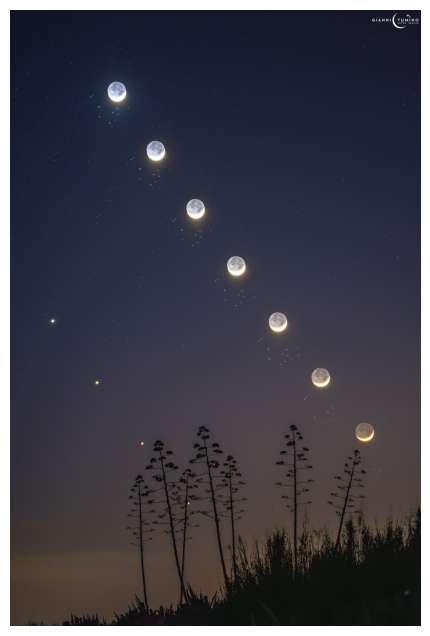

In [28]:
import json
import requests 

# Carregando a chave de API do arquivo
with open('key.json', 'r') as fp:
    auth = json.load(fp)

## definindo atributos constantes
API_KEY = auth['API_KEY']
BASE_URL = "https://api.nasa.gov/planetary/apod"

headers = {
#    "Content-Type": "application/json",
#    "x-api-key": API_KEY
}

## definindo os outros atributos do request
endpoint = ''

## executando GET request
res = requests.get(
    BASE_URL+endpoint,
    headers=headers,
    params={'api_key': API_KEY}
)

data = res.json()

print("Copyright:", data.get('copyright'))
print("\nExplanation:", data.get('explanation'))

#IMAGEM
import matplotlib.pyplot as plt
from skimage import io

url = data.get('hdurl') or data.get('url')
img = io.imread(url)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.show()

#### Q3. Limites
A partir da resposta da query anterios, imprima o header da resposta e consulte os atributos:
* X-RateLimit-Limit: o limite total de requisições da sua chave de API
* X-RateLimit-Remaining: o limite restante de requisições da sua chave de API

In [2]:
# Imprimindo o header da resposta
print("Headers da resposta:")
print(res.headers)
print("\n" + "="*50 + "\n")

# Extraindo os limites de requisição
rate_limit = res.headers.get('X-RateLimit-Limit')
rate_remaining = res.headers.get('X-RateLimit-Remaining')

print(f"X-RateLimit-Limit (limite total): {rate_limit}")
print(f"X-RateLimit-Remaining (limite restante): {rate_remaining}")

Headers da resposta:
{'Date': 'Wed, 29 Apr 2026 16:06:03 GMT', 'Content-Type': 'application/json', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Access-Control-Allow-Origin': '*', 'Access-Control-Expose-Headers': 'X-RateLimit-Limit, X-RateLimit-Remaining', 'Age': '0', 'Content-Encoding': 'gzip', 'Referrer-Policy': 'strict-origin-when-cross-origin', 'Strict-Transport-Security': 'max-age=31536000; includeSubDomains; preload', 'Vary': 'Accept-Encoding', 'Via': 'https/1.1 api-umbrella (ApacheTrafficServer [cMsSf ])', 'X-Api-Umbrella-Request-Id': 'ctr7uo8jsb2t2o6ttqj0', 'X-Cache': 'MISS', 'X-Content-Type-Options': 'nosniff', 'X-Powered-By': 'appdat', 'X-Ratelimit-Limit': '4000', 'X-Ratelimit-Remaining': '3993', 'X-Using-Nginx-Controller': 'true', 'X-Vcap-Request-Id': '44873d53-4bf2-4568-5fdd-932a3c752bdf', 'X-Xss-Protection': '1; mode=block', 'X-Frame-Options': 'SAMEORIGIN'}


X-RateLimit-Limit (limite total): 4000
X-RateLimit-Remaining (limite restante): 3993


### Q4. Mars Rover Photos 🚀🚙 📷

<img width=500 src=https://www.nasa.gov/wp-content/uploads/2019/10/pia23378-16.jpg>

Essa API retorna dados (incluindo imagens capturadas) sobre os veículos que hoje habitam o planeta Marte. São os rovers `opportunity`, `spirit` e o mais famoso, o `curiosity` (da foto acima).

Antes de requisitar imagens, vamos ver o relatório de dados coletados por um deles, o `curiosity`. Isso vai nos ajudar a montar a query de imagens coletadas.

Faça uma requisição GET para a seguinte URL:
* URL base: `'https://api.nasa.gov/mars-photos/api/v1'`
* endpoint: `'/manifests/{nome_do_rover}'`
* query parameters: preencha `api_key` com a sua chave de autenticação.

Extraia o json da resposta retornada. O campo principal é o `'photo_manifest'`, do qual queremos acessar os seguintes valores:
* `max_sol`: Máximo "dia marciano" de coleta de fotos. O dia marciano tem 24 horas, 39 minutos e 35 segundos.
* `max_date`: Última data terrestre de coleta de fotos, na forma `'aaaa-mm-dd'`.

Imprima esses dois atributos da resposta e os use no próximo exercício para coletar as fotos mais recentes tiradas. 

In [26]:
import json
import requests 

# Carregando a chave de API do arquivo
with open('key.json', 'r') as fp:
    auth = json.load(fp)

## definindo atributos constantes
API_KEY = auth['API_KEY']
BASE_URL = "https://api.nasa.gov/mars-photos/api/v1"

headers = {
#    "Content-Type": "application/json",
#    "x-api-key": API_KEY
}

nome_do_rover = "curiosity"

## definindo os outros atributos do request
endpoint = f'/manifests/{nome_do_rover}'

## executando GET request
res = requests.get(
    BASE_URL+endpoint,
    headers=headers,
    params={'api_key': API_KEY}
)
#print(res.url) https://api.nasa.gov/mars-photos/api/v1/manifests/curiosity?api_key=OvseWoETgY84x4edQxJiv7WNrilv04aKcdUOm58w
#print(res.status_code) 404
#A API mudou, não tem mais o endpoint /manifests/{nome_do_rover}

data = res.json()

print("Max_sol:", data.get('max_sol'))
print("\nMax_date:", data.get('max_date'))



https://api.nasa.gov/mars-photos/api/v1/manifests/curiosity?api_key=OvseWoETgY84x4edQxJiv7WNrilv04aKcdUOm58w
404


#### Q5.

Faça uma requisição GET para a URL da API que retorna links para as imagens coletadas pelos rovers.

* URL base: `'https://api.nasa.gov/mars-photos/api/v1'`
* Endpoint: `/rovers/{nome_do_rover}/photos`
* Query params sugeridos: 
    * `api_key`: sua chave de autenticação.
    * `sol`: dia marciano que deseja coletar (de 0 a `max_sol` coletado anteriormente)
    * `page`: você pode paginar entre as respostas! São retornados 25 resultados por página.

A resposta esperada estará no formato a seguir, uma lista no campo `'photos'` onde cada item é um dicionário com os dados da foto tirada. Dentre os dados há o campo `camera` indicando qual das câmeras do rover tirou a foto. As fotos mais interessantes (na minha opinião, claro) são das câmeras de navegação (`"name": "NAVCAM"`) e as de prevenção de colisão (frente: `"name": "FHAZ"` e trás `"name": "RHAZ"`) onde dá pra ver partes do robô!

**Seu trabalho é**:
* Paginar a requisição acima até que a resposta seja `None`
* Escolher uma ou mais câmeras (ex: `NAVCAM`, `FHAZ`, `RHAZ`), e em um laço de repetição plotar todas as imagens retornadas daquela câmera. Use novamente as bibliotecas scikit-image e matplotlib. 
  * O título da imagem deve ter a página da requisição, nome da câmera e id da imagem.

```json
{
  "photos": [
    {
      "id": 1228212,
      "sol": 4102,
      "camera": {
        "id": 20,
        "name": "FHAZ",
        "rover_id": 5,
        "full_name": "Front Hazard Avoidance Camera"
      },
      "img_src": "https://mars.nasa.gov/msl-raw-images/proj/msl/redops/ods/surface/sol/04102/opgs/edr/fcam/FLB_761645828EDR_F1060660FHAZ00302M_.JPG",
      "earth_date": "2024-02-19",
      "rover": {
        "id": 5,
        "name": "Curiosity",
        ...
      }
    }
    {
      "id": 1228213,
      "sol": 4102, 
      ...
    }
```



In [36]:
import json
import requests 
import matplotlib.pyplot as plt
from skimage import io

# Carregando a chave de API do arquivo
with open('key.json', 'r') as fp:
    auth = json.load(fp)

## definindo atributos constantes
API_KEY = auth['API_KEY']
BASE_URL = "https://api.nasa.gov/mars-photos/api/v1"

headers = {
#    "Content-Type": "application/json",
#    "x-api-key": API_KEY
}

nome_do_rover = "curiosity"

## definindo os outros atributos do request
endpoint = f"/rovers/{nome_do_rover}/photos"
############### O endpoint não está mais disponível, a API mudou

page = 1
while True:
    ##executando GET request
    res = requests.get(
        BASE_URL + endpoint,
        params={'page': page, 'api_key': API_KEY,'sol': 1000})
    photos = res.json().get('photos', [])
    
    if not photos:
        break

    # filtro
    for photo in photos:
        if photo.get('name') =='FHAZ'or photo.get('name') =='RHAZ' or photo.get('name') =='NAVCAM':
            url = photo.get('img_src')
            img = io.imread(url)

            plt.figure(figsize=(12, 8))
            plt.imshow(img)
            plt.title(f"Pagina: {page}, Camera:{photo.get('name')}, ID: {photo.get('id')}")
            plt.axis('off')
            plt.show()
    
    page += 1




JSONDecodeError: Expecting value: line 1 column 1 (char 0)